## Assumptions
The analysis makes the following assumptions:
1.	Brent crude oil prices accurately represent global crude oil market conditions.
2.	Event dates are treated as the beginning of market reactions, although markets may respond before or after official announcements.
3.	Each major geopolitical or economic event is assumed to have the potential to influence oil prices independently.
4.	Daily closing prices sufficiently capture market responses.
5.	External factors not included in the event dataset (weather, currency fluctuations, speculation, technological changes, etc.) are assumed to have smaller or random effects.


## Limitations
Several limitations should be acknowledged.
### Correlation vs Causation
The most important limitation is that statistical analysis identifies temporal associations, not definitive causal relationships.
A change point occurring shortly after a geopolitical event does not prove that the event caused the price change. Other unobserved factors may have influenced the market simultaneously.
Therefore, findings should be interpreted as evidence of statistical correlation, supported by economic reasoning, rather than proof of causality.
### Other Limitations
·	Markets often react before official announcements due to expectations and leaked information.
·	Multiple events can occur simultaneously, making it difficult to isolate individual effects.
·	Some geopolitical events unfold gradually rather than occurring on a single date.
·	Oil prices are also influenced by exchange rates, inflation, speculation, technological advances, and macroeconomic conditions that are not explicitly modeled.
·	Bayesian Change Point Analysis detects statistical shifts but does not identify the underlying cause of those shifts.


## Event dataset 
| Date       | Event                         | Category     | Expected Impact       |
| ---------- | ----------------------------- | ------------ | --------------------- |
| 1990-08-02 | Iraq invades Kuwait           | Conflict     | Sharp price increase  |
| 1991-01-17 | Gulf War begins               | Conflict     | Increased volatility  |
| 1997-07-02 | Asian Financial Crisis        | Economic     | Reduced oil demand    |
| 1998-03-30 | OPEC Production Cuts          | OPEC         | Price recovery        |
| 2001-09-11 | September 11 Attacks          | Geopolitical | Demand uncertainty    |
| 2003-03-20 | Iraq War                      | Conflict     | Supply concerns       |
| 2008-09-15 | Global Financial Crisis       | Economic     | Large price decline   |
| 2010-12-18 | Arab Spring                   | Political    | Supply disruptions    |
| 2014-11-27 | OPEC Maintains Production     | OPEC         | Price collapse        |
| 2016-11-30 | OPEC Production Cut Agreement | OPEC         | Price increase        |
| 2018-11-05 | US Sanctions on Iran          | Sanctions    | Supply concerns       |
| 2020-03-06 | OPEC+ Price War               | OPEC         | Price collapse        |
| 2020-03-11 | COVID-19 Declared Pandemic    | Economic     | Historic demand shock |
| 2021-07-18 | OPEC+ Production Increase     | OPEC         | Supply stabilization  |
| 2022-02-24 | Russia Invades Ukraine        | Conflict     | Sharp price increase  |


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
import pymc as pm
import json

## 2. Load Data

In [2]:
df = pd.read_csv("../data/BrentOilPrices.csv")

df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date").reset_index(drop=True)

C:\Users\hp\AppData\Local\Temp\ipykernel_3664\907172931.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"])


## 3. Exploratory Data Analysis

### Plot Brent Prices

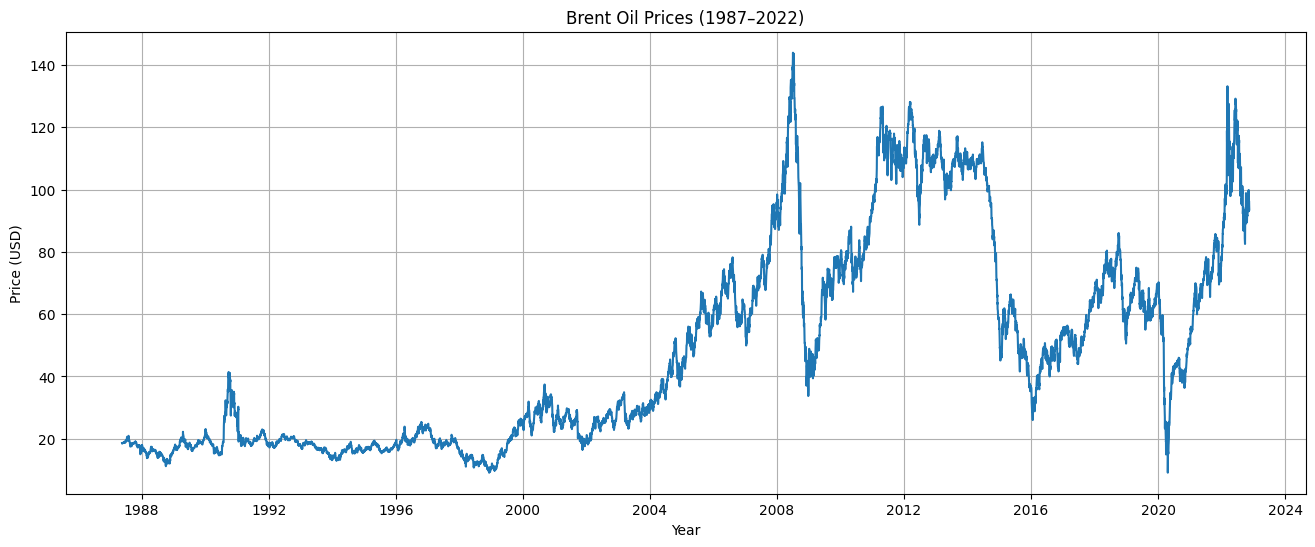

In [3]:
plt.figure(figsize=(16,6))
plt.plot(df["Date"], df["Price"])
plt.title("Brent Oil Prices (1987–2022)")
plt.xlabel("Year")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.show()

### Calculate Log Returns

In [4]:
df["Log_Return"] = np.log(df["Price"]).diff()

df = df.dropna()

### Plot Log Returns

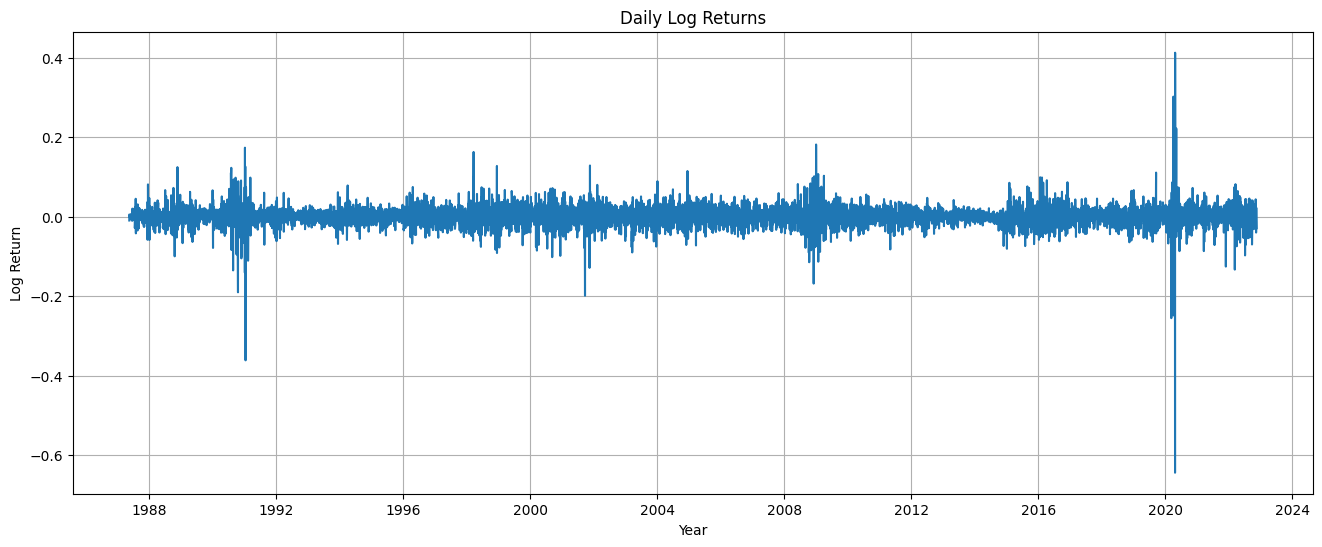

In [5]:
plt.figure(figsize=(16,6))
plt.plot(df["Date"], df["Log_Return"])
plt.title("Daily Log Returns")
plt.xlabel("Year")
plt.ylabel("Log Return")
plt.grid(True)
plt.show()

## 4. Bayesian Change Point Model

In [6]:
returns = df["Log_Return"].values

n = len(returns)

time = np.arange(n)

### Build the Model

In [7]:
with pm.Model() as model:

    tau = pm.DiscreteUniform(
        "tau",
        lower=0,
        upper=n-1
    )

    mu1 = pm.Normal(
        "mu1",
        mu=0,
        sigma=1
    )

    mu2 = pm.Normal(
        "mu2",
        mu=0,
        sigma=1
    )

    sigma = pm.HalfNormal(
        "sigma",
        sigma=1
    )

    mu = pm.math.switch(
        time < tau,
        mu1,
        mu2
    )

    likelihood = pm.Normal(
        "likelihood",
        mu=mu,
        sigma=sigma,
        observed=returns
    )

    trace = pm.sample(
        draws=3000,
        tune=1000,
        target_accept=0.95,
        return_inferencedata=True
    )

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu1, mu2, sigma]


Output()

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 114 seconds.
Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


## 5. Convergence Diagnostics

In [8]:
az.summary(trace)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
tau,5e+03,3e+03,25,9000,13,15,1.23,960,330
mu1,-0.01,0.09,-0.0021,0.0013,591,31,1.12,0.011,0.049
mu2,-0,0.008,-0.0015,0.0037,28,31,1.11,0.00092,0.0035
sigma,0.025535,0.000192,0.025,0.026,4668,5084,1.00,2.8e-06,2e-06


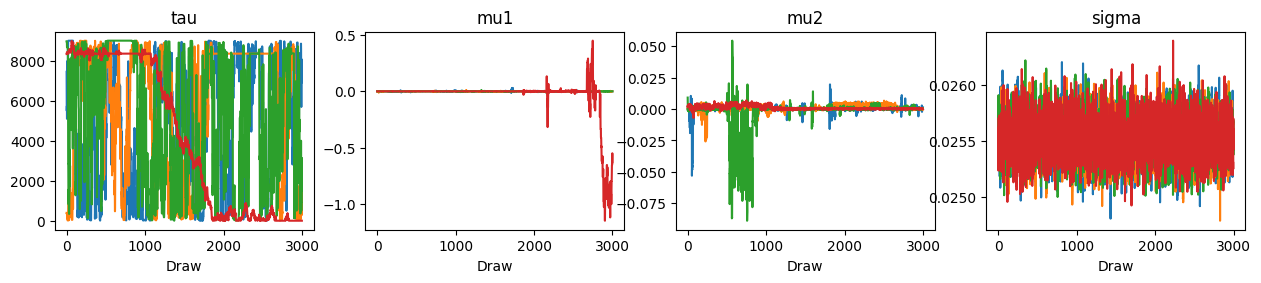

In [9]:
az.plot_trace(trace)
plt.show()

## 6. Posterior Distribution of Change Point

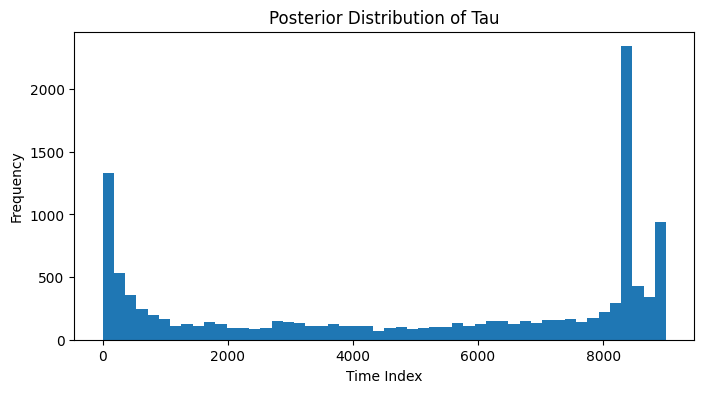

In [10]:
tau_samples = trace.posterior["tau"].values.flatten()

plt.figure(figsize=(8,4))
plt.hist(tau_samples, bins=50)
plt.title("Posterior Distribution of Tau")
plt.xlabel("Time Index")
plt.ylabel("Frequency")
plt.show()

In [11]:
tau_samples = trace.posterior["tau"].values.flatten()

estimated_tau = int(np.mean(tau_samples))

estimated_date = df.iloc[estimated_tau]["Date"]

print(estimated_date)

2007-06-20 00:00:00


## 7. Posterior Distributions

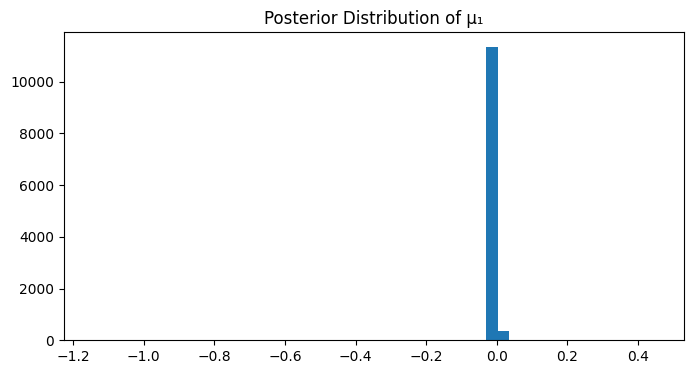

In [12]:
mu1_samples = trace.posterior["mu1"].values.flatten()

plt.figure(figsize=(8,4))
plt.hist(mu1_samples, bins=50)
plt.title("Posterior Distribution of μ₁")
plt.show()

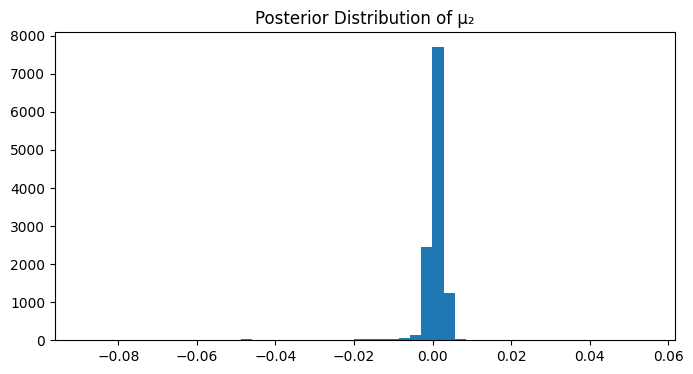

In [13]:
mu2_samples = trace.posterior["mu2"].values.flatten()

plt.figure(figsize=(8,4))
plt.hist(mu2_samples, bins=50)
plt.title("Posterior Distribution of μ₂")
plt.show()

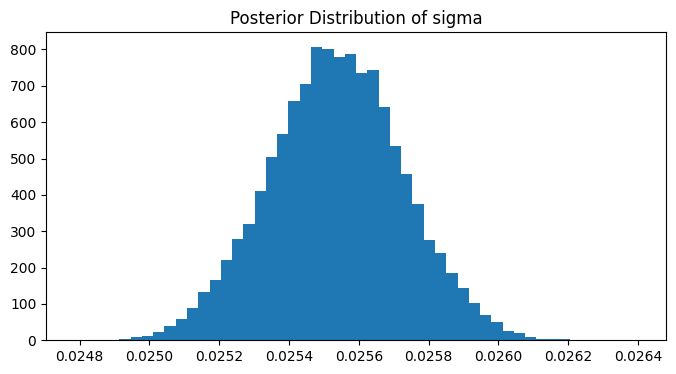

In [14]:
sigma_samples = trace.posterior["sigma"].values.flatten()

plt.figure(figsize=(8,4))
plt.hist(sigma_samples, bins=50)
plt.title("Posterior Distribution of sigma")
plt.show()

## 8. Visualize Detected Change Point

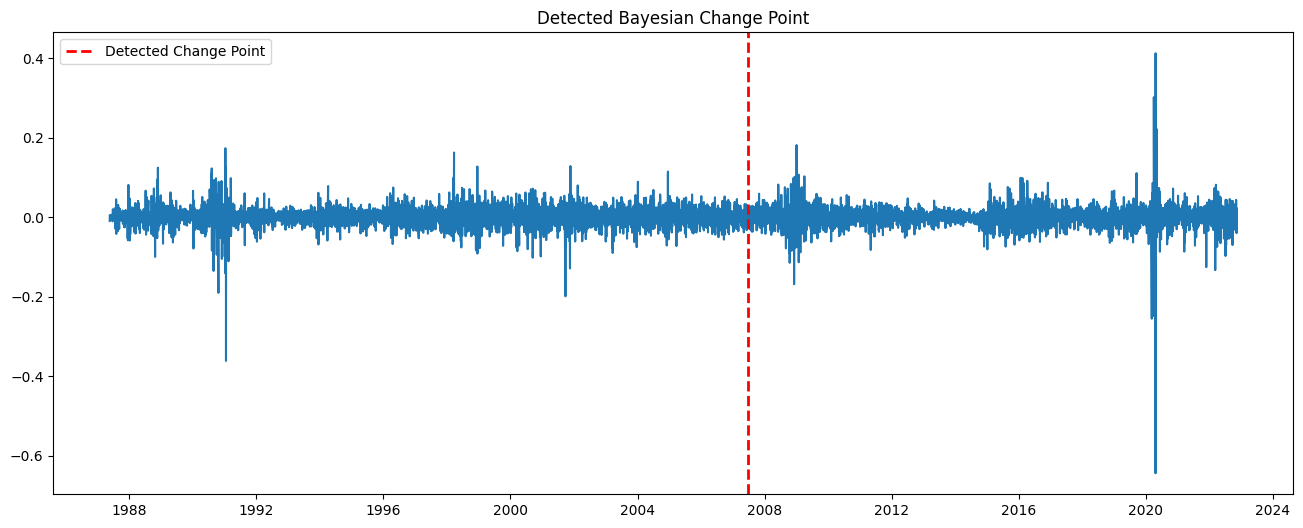

In [15]:
plt.figure(figsize=(16,6))

plt.plot(df["Date"], returns)

plt.axvline(
    estimated_date,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Detected Change Point"
)

plt.legend()

plt.title("Detected Bayesian Change Point")

plt.show()

## Save model results

In [16]:
# Posterior samples
tau_samples = trace.posterior["tau"].values.flatten()
mu1_samples = trace.posterior["mu1"].values.flatten()
mu2_samples = trace.posterior["mu2"].values.flatten()
sigma_samples = trace.posterior["sigma"].values.flatten()

# Estimated change point
estimated_tau = int(np.mean(tau_samples))
estimated_date = str(df.iloc[estimated_tau]["Date"].date())

# 95% credible interval for tau
lower_tau = int(np.percentile(tau_samples, 2.5))
upper_tau = int(np.percentile(tau_samples, 97.5))

model_results = {

    "change_point": estimated_date,

    "change_point_index": estimated_tau,

    "mu_before": round(float(mu1_samples.mean()), 6),

    "mu_after": round(float(mu2_samples.mean()), 6),

    "sigma": round(float(sigma_samples.mean()), 6),

    "credible_interval": {

        "lower": str(df.iloc[lower_tau]["Date"].date()),

        "upper": str(df.iloc[upper_tau]["Date"].date())

    }

}

with open("../data/model_results.json", "w") as f:

    json.dump(model_results, f, indent=4)

print("model_results.json created successfully!")

model_results.json created successfully!
